In [1]:
!pip install -e /home/aku7cf/DREAMS/DREAMS_python
# !pip install -e /path/to/DREAMS_python

Defaulting to user installation because normal site-packages is not writeable
Obtaining file:///home/aku7cf/DREAMS/DREAMS_python
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for dreams_python (pyproject.toml) ... done
  Created wheel for dreams_python: filename=dreams_python-0.1.0-0.editable-py3-none-any.whl size=4485 sha256=3d3899e26080df4aca1ab7f60b646f23a8efd1a2adba2696040865815454ed88
  Stored in directory: /tmp/pip-ephem-wheel-cache-ult96ojz/wheels/93/9c/36/d4c59b3fc31ec2b5dc143e4a986198ab2224d05d41a91e194c
Successfully built dreams_python
  Attempting uninstall: dreams_python
    Found existing installation: dreams_python 0.1.0
    Uninstalling dreams_python-0.1.0:
      Successfully uninstalled dreams_python-0.1.0


In [2]:
import dreams_python

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Load in data (as normal)

In [12]:
wdm_boxes = dreams_python.DREAMS('/standard/DREAMS',suite='boxes',DM_type='WDM',sobol_number=6)

run = 1
snap = 90

grp_cat = wdm_boxes.read_group_catalog(run, snap)
prt_cat = wdm_boxes.read_snapshot(run, snap)

box_size = wdm_boxes.get_box_size(run, snap)

The whole volume is PartType1 (no low resolution Dark Matter or baryons)

In [15]:
print(prt_cat.keys())

dict_keys(['PartType1/Coordinates', 'PartType1/ParticleIDs', 'PartType1/Potential', 'PartType1/SubfindDMDensity', 'PartType1/SubfindDensity', 'PartType1/SubfindHsml', 'PartType1/SubfindVelDisp', 'PartType1/Velocities', 'PartType1/Masses'])


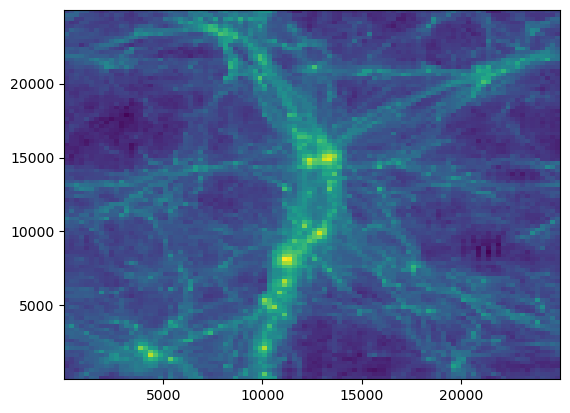

In [11]:
dm_pos  = prt_cat['PartType1/Coordinates']
dm_mass = prt_cat['PartType1/Masses']

grp_cat['GroupPos']

mask_z = dm_pos[:, 2] < box_size / 5


plt.hist2d(prt_cat['PartType1/Coordinates'][mask_z, 0], prt_cat['PartType1/Coordinates'][mask_z, 1],
           bins=100, norm='log', rasterized=True)

plt.show()